# Fake News Detection with DistilBERT

Group 01
- Alonso Geesink Anton ()
- Claudio Vincenzo Catalano Leiva (claudio.catalano.leiva@alumnos.upm.es)
- Seyit Ahmet Inci ()

Deep Learning Course 2025/26 - Course Project: Exercise 2 - Fine-tuning the Model with Experimentation

**Dataset**: [Fake News Detection Datasets](https://www.kaggle.com/datasets/emineyetm/fake-news-detection-datasets/data)

**Code References using DistilBERT**:
- https://www.kaggle.com/code/henryukwuoma/fake-and-real-news-distilbert
- https://www.kaggle.com/code/shehabmagdy710/distilbert-fine-tuning-on-fake-news-data

## 1. Setup and Imports

In [ ]:
# Install required packages if needed
# !pip install transformers datasets torch pandas numpy scikit-learn matplotlib seaborn tqdm accelerate

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from tqdm.auto import tqdm

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. Loading and Processing the Data from the Kaggle Dataset

Note: Before running this for our training, remember to check that the data files are in your local folder! You can find them from the dataset from Kaggle and place the CSV files in a `data/` directory.
Expected files:
- `Fake.csv`: Contains fake news articles
- `True.csv`: Contains true news articles

In [2]:
# Load the datasets
fake_df = pd.read_csv('data/Fake.csv')
true_df = pd.read_csv('data/True.csv')

# Add labels: 0 for fake, 1 for true
fake_df['label'] = 0
true_df['label'] = 1

# Combine the datasets so that we just have one file
df = pd.concat([fake_df, true_df], ignore_index=True)

# Shuffle the dataset to ensure random distribution for our training
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Total samples: {len(df)}")
print(f"Fake news: {len(fake_df)} ({len(fake_df)/len(df)*100:.2f}%)")
print(f"True news: {len(true_df)} ({len(true_df)/len(df)*100:.2f}%)")
print("\nDataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Total samples: 44898
Fake news: 23481 (52.30%)
True news: 21417 (47.70%)

Dataset shape: (44898, 5)

Columns: ['title', 'text', 'subject', 'date', 'label']


In [3]:
# Display first few rows
df.head()

,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


In [4]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Basic statistics
print("\nLabel distribution:")
print(df['label'].value_counts())

Missing values:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Label distribution:
label
0    23481
1    21417
Name: count, dtype: int64


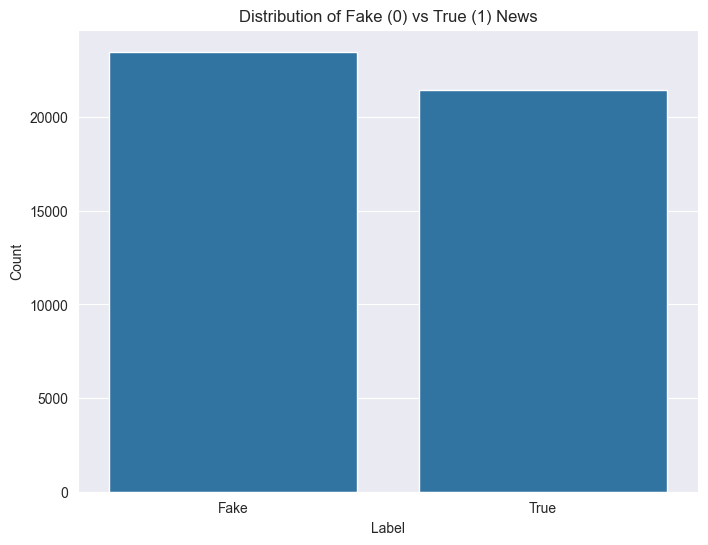

In [5]:
# Visualize label distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='label')
plt.title('Distribution of Fake (0) vs True (1) News')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks([0, 1], ['Fake', 'True'])
plt.show()

## 3. Data Preprocessing

Combine title and text for a more comprehensive input to the model.

In [ ]:
# Combine title and text (if they exist)
if 'title' in df.columns and 'text' in df.columns:
    df['content'] = df['title'] + ' ' + df['text']
elif 'text' in df.columns:
    df['content'] = df['text']
elif 'title' in df.columns:
    df['content'] = df['title']
else:
    # Find the text column
    text_cols = [col for col in df.columns if col not in ['label', 'subject', 'date']]
    if text_cols:
        df['content'] = df[text_cols[0]]
    else:
        raise ValueError("Could not find text column in dataset")

# Remove rows with missing content
df = df.dropna(subset=['content'])
df = df[df['content'].str.strip() != '']

print(f"Dataset size after cleaning: {len(df)}")
print(f"Average content length: {df['content'].str.len().mean():.0f} characters")

In [ ]:
# Split the data into train, validation, and test sets
# First split: 80% train+val, 20% test
train_val_df, test_df = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df['label']
)

# Second split: 80% train, 20% val from the train+val set
train_df, val_df = train_test_split(
    train_val_df, test_size=0.2, random_state=SEED, stratify=train_val_df['label']
)

print(f"Training set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")

## 4. Tokenization and Dataset Preparation

In [ ]:
# Load DistilBERT tokenizer
# Note: Using AutoTokenizer for better compatibility
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Tokenizer loaded: {MODEL_NAME}")

In [ ]:
# Define custom dataset class
class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
# Configuration
MAX_LENGTH = 512
BATCH_SIZE = 16
EPOCHS = 3
LEARNING_RATE = 2e-5

# Create datasets
train_dataset = FakeNewsDataset(
    texts=train_df['content'].values,
    labels=train_df['label'].values,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

val_dataset = FakeNewsDataset(
    texts=val_df['content'].values,
    labels=val_df['label'].values,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

test_dataset = FakeNewsDataset(
    texts=test_df['content'].values,
    labels=test_df['label'].values,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

## 5. Model Setup

In [ ]:
# Load pre-trained DistilBERT model
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)
model = model.to(device)

print(f"Model loaded and moved to {device}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

In [ ]:
# Setup optimizer and scheduler
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, eps=1e-8)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

print(f"Total training steps: {total_steps}")

## 6. Training Functions

In [ ]:
def train_epoch(model, data_loader, optimizer, scheduler, device):
    """
    Train the model for one epoch.
    """
    model.train()
    losses = []
    correct_predictions = 0
    total_predictions = 0
    
    progress_bar = tqdm(data_loader, desc='Training')
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        logits = outputs.logits
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        # Calculate accuracy
        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == labels)
        total_predictions += labels.size(0)
        losses.append(loss.item())
        
        # Update progress bar
        progress_bar.set_postfix({
            'loss': loss.item(),
            'acc': (correct_predictions.double() / total_predictions).item()
        })
    
    return correct_predictions.double() / total_predictions, np.mean(losses)

In [ ]:
def eval_model(model, data_loader, device):
    """
    Evaluate the model.
    """
    model.eval()
    losses = []
    correct_predictions = 0
    total_predictions = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        progress_bar = tqdm(data_loader, desc='Evaluating')
        
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            loss = outputs.loss
            logits = outputs.logits
            
            _, preds = torch.max(logits, dim=1)
            correct_predictions += torch.sum(preds == labels)
            total_predictions += labels.size(0)
            losses.append(loss.item())
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return (
        correct_predictions.double() / total_predictions,
        np.mean(losses),
        np.array(all_preds),
        np.array(all_labels)
    )

## 7. Training Loop

In [ ]:
# Training history
history = {
    'train_acc': [],
    'train_loss': [],
    'val_acc': [],
    'val_loss': []
}

best_val_acc = 0

for epoch in range(EPOCHS):
    print(f'\n{"=" * 50}')
    print(f'Epoch {epoch + 1}/{EPOCHS}')
    print(f'{"=" * 50}')
    
    # Training
    train_acc, train_loss = train_epoch(
        model, train_loader, optimizer, scheduler, device
    )
    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
    
    # Validation
    val_acc, val_loss, _, _ = eval_model(model, val_loader, device)
    print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')
    
    # Save history
    history['train_acc'].append(train_acc.item())
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc.item())
    history['val_loss'].append(val_loss)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pt')
        print(f'✓ Best model saved with validation accuracy: {best_val_acc:.4f}')

print(f'\n{"=" * 50}')
print('Training completed!')
print(f'{"=" * 50}')

## 8. Training Visualization

In [ ]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
ax1.plot(history['train_acc'], label='Train Accuracy', marker='o')
ax1.plot(history['val_acc'], label='Validation Accuracy', marker='o')
ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history['train_loss'], label='Train Loss', marker='o')
ax2.plot(history['val_loss'], label='Validation Loss', marker='o')
ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Model Evaluation on Test Set

In [ ]:
# Load the best model
model.load_state_dict(torch.load('best_model.pt'))
print("Best model loaded for testing")

# Evaluate on test set
test_acc, test_loss, test_preds, test_labels = eval_model(model, test_loader, device)

print(f'\nTest Results:')
print(f'{"=" * 50}')
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

In [ ]:
# Detailed classification report
print('\nClassification Report:')
print('=' * 50)
print(classification_report(
    test_labels, 
    test_preds, 
    target_names=['Fake', 'True'],
    digits=4
))

In [ ]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Fake', 'True'],
    yticklabels=['Fake', 'True']
)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate additional metrics
precision, recall, f1, _ = precision_recall_fscore_support(
    test_labels, test_preds, average='weighted'
)

print(f'\nAdditional Metrics:')
print(f'{"=" * 50}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

## 10. Inference Function

In [ ]:
def predict_news(text, model, tokenizer, device, max_length=512):
    """
    Predict whether a news article is fake or true.
    
    Args:
        text: News article text
        model: Trained model
        tokenizer: Tokenizer
        device: Device to run inference on
        max_length: Maximum sequence length
    
    Returns:
        prediction: 'Fake' or 'True'
        confidence: Confidence score (0-1)
    """
    model.eval()
    
    encoding = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)
        confidence, predicted_class = torch.max(probs, dim=1)
    
    prediction = 'True' if predicted_class.item() == 1 else 'Fake'
    
    return prediction, confidence.item()

## 11. Test Inference with Examples

In [ ]:
# Test with some random samples from test set
sample_indices = np.random.choice(len(test_df), size=5, replace=False)

print('Sample Predictions:')
print('=' * 80)

for idx in sample_indices:
    sample = test_df.iloc[idx]
    text = sample['content'][:500]  # Show first 500 characters
    true_label = 'True' if sample['label'] == 1 else 'Fake'
    
    prediction, confidence = predict_news(
        sample['content'], model, tokenizer, device
    )
    
    print(f'\nText: {text}...')
    print(f'True Label: {true_label}')
    print(f'Predicted: {prediction} (Confidence: {confidence:.4f})')
    print('-' * 80)

In [ ]:
# Test with custom text
custom_text = """
Scientists have discovered a new species of dinosaur in Argentina. 
The fossil, believed to be 95 million years old, was found by paleontologists 
working in the Patagonia region. The discovery provides new insights into 
the evolution of carnivorous dinosaurs.
"""

prediction, confidence = predict_news(custom_text, model, tokenizer, device)
print(f'\nCustom Text Prediction:')
print(f'Predicted: {prediction}')
print(f'Confidence: {confidence:.4f}')

## 12. Save Model and Tokenizer

In [ ]:
# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the model and tokenizer
model.save_pretrained('models/fake_news_distilbert')
tokenizer.save_pretrained('models/fake_news_distilbert')

print('Model and tokenizer saved to models/fake_news_distilbert/')

## 13. Summary

This notebook demonstrated:

1. **Data Loading**: Loaded fake and true news datasets from Kaggle
2. **Preprocessing**: Combined text fields and split into train/val/test sets
3. **Tokenization**: Used DistilBERT tokenizer to prepare text data
4. **Model Training**: Fine-tuned DistilBERT for binary classification
5. **Evaluation**: Achieved high accuracy on test set with detailed metrics
6. **Inference**: Created a function to predict on new articles

### Next Steps:

- Experiment with different hyperparameters (learning rate, batch size, epochs)
- Try data augmentation techniques
- Test with other BERT variants (BERT-base, RoBERTa, ALBERT)
- Deploy the model as a web service
- Collect more diverse training data to improve generalization